In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset

In [6]:
df = pd.read_csv("../data/accidentes.csv")

df.head()

C:\Users\conto\AppData\Local\Temp\ipykernel_16568\1906795077.py:1: DtypeWarning: Columns (0: EDAD_VEHICULO) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/accidentes.csv")


,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO
0,HONDA,2017,MOTOCICLETA,9.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
1,CHEVROLET,2007,CAMION,20.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
2,JEEP,2017,CAMPERO,9.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
3,CHEVROLET,2023,CAMIONETA,2.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
4,HONDA,2026,MOTOCICLETA,1.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA


#General information about the dataset

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 406540 entries, 0 to 406539
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   MARCA_VEHICULO          406496 non-null  str   
 1   MODELO_VEHICULO         406540 non-null  int64 
 2   TIPO_VEHICULO           406540 non-null  str   
 3   EDAD_VEHICULO           406520 non-null  object
 4   FECHA_ACCIDENTE         406540 non-null  str   
 5   GRAVEDAD_ACCIDENTE      406540 non-null  str   
 6   DEPARTAMENTO_ACCIDENTE  406540 non-null  str   
 7   MUNICIPIO_ACCIDENTE     406540 non-null  str   
 8   AUTORIDAD_DE_TRANSITO   406540 non-null  str   
dtypes: int64(1), object(1), str(7)
memory usage: 27.9+ MB


In [8]:
df.shape

(406540, 9)

In [9]:
df.describe()

,MODELO_VEHICULO
count,406540.000000
mean,2015.587573
std,7.817606
min,1937.000000
25%,2012.000000
50%,2017.000000
75%,2021.000000
max,2027.000000


#Null value analysis

#Detect duplicates

In [10]:
df.isnull().sum()

MARCA_VEHICULO            44
MODELO_VEHICULO            0
TIPO_VEHICULO              0
EDAD_VEHICULO             20
FECHA_ACCIDENTE            0
GRAVEDAD_ACCIDENTE         0
DEPARTAMENTO_ACCIDENTE     0
MUNICIPIO_ACCIDENTE        0
AUTORIDAD_DE_TRANSITO      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(147561)

In [13]:
df[df.duplicated()]

,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO
11,HONDA,2026,MOTOCICLETA,1.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
19,BERA,2025,MOTOCICLETA,0.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
28,BERA,2025,MOTOCICLETA,0.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
37,HERO,2026,MOTOCICLETA,0.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
47,TVS,2025,MOTOCICLETA,1.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
...,...,...,...,...,...,...,...,...,...
406530,YAMAHA,2016,MOTOCICLETA,10.0,01/2022,CON HERIDOS,ATLANTICO,BARRANQUILLA,STRIA DTAL TTO BARRANQUILLA
406531,AKT,2014,MOTOCICLETA,13.0,01/2022,CON HERIDOS,ATLANTICO,BARRANQUILLA,STRIA DTAL TTO BARRANQUILLA
406533,AKT,2022,MOTOCICLETA,4.0,01/2022,CON HERIDOS,ATLANTICO,BARRANQUILLA,STRIA DTAL TTO BARRANQUILLA
406534,BAJAJ,2021,MOTOCICLETA,5.0,01/2022,CON HERIDOS,ATLANTICO,BARRANQUILLA,STRIA DTAL TTO BARRANQUILLA


#Validate data types

In [14]:
df.dtypes

MARCA_VEHICULO               str
MODELO_VEHICULO            int64
TIPO_VEHICULO                str
EDAD_VEHICULO             object
FECHA_ACCIDENTE              str
GRAVEDAD_ACCIDENTE           str
DEPARTAMENTO_ACCIDENTE       str
MUNICIPIO_ACCIDENTE          str
AUTORIDAD_DE_TRANSITO        str
dtype: object

#Distribution of important variables

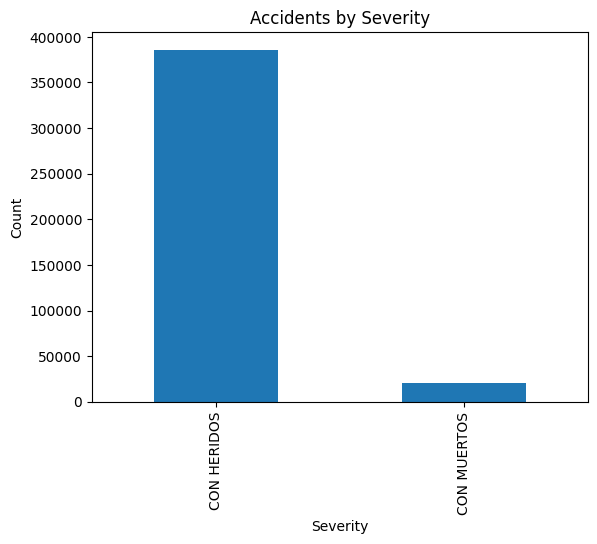

In [21]:
df['GRAVEDAD_ACCIDENTE'].value_counts().plot(kind='bar')

plt.title("Accidents by Severity")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

#identify anomalous values.

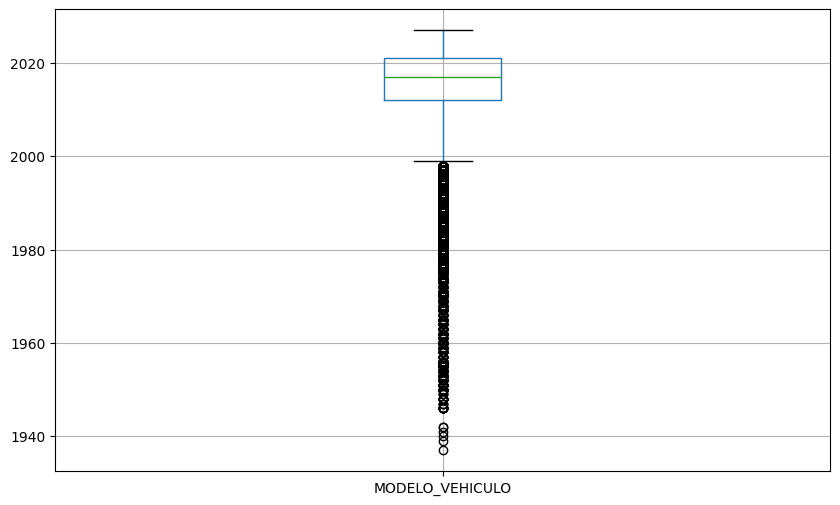

In [22]:
df.boxplot(figsize=(10,6))
plt.show()

#Unique values

In [23]:
df.nunique()

MARCA_VEHICULO            360
MODELO_VEHICULO            87
TIPO_VEHICULO              28
EDAD_VEHICULO             165
FECHA_ACCIDENTE            50
GRAVEDAD_ACCIDENTE          2
DEPARTAMENTO_ACCIDENTE     31
MUNICIPIO_ACCIDENTE       639
AUTORIDAD_DE_TRANSITO     232
dtype: int64

#Example of temporal analysis

In [24]:
df['FECHA_ACCIDENTE'] = pd.to_datetime(df['FECHA_ACCIDENTE'])

df['FECHA_ACCIDENTE'].dt.year.value_counts()

C:\Users\conto\AppData\Local\Temp\ipykernel_16568\841436722.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['FECHA_ACCIDENTE'] = pd.to_datetime(df['FECHA_ACCIDENTE'])


FECHA_ACCIDENTE
2024    120342
2022    114478
2023    111609
2025     57867
2026      2244
Name: count, dtype: int64

#Conclusions

#Key Findings

- The dataset contains more than 50,000 records.
- Some columns contain missing values.
- A small number of duplicate records were detected.
- Data types need to be standardized.
- Several categorical variables will be used to build dimension tables.

These issues will be addressed during the transformation phase of the ETL pipeline.